### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay)
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostClassifier
import joblib

In [2]:
train_df = pd.read_csv('../data/student_health_risk_train.csv')
test_df = pd.read_csv('../data/student_health_risk_test.csv')

train_df.sample(5)



,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
70713,70713,at-risk,6.65,64.7,21.27,2189.0,8820.0,51.6,2.05,veg,high,good,moderate,no,male
591038,591038,at-risk,NaN,66.7,21.07,1640.0,7659.0,39.7,2.33,non-veg,medium,poor,moderate,occasional,other
363948,363948,at-risk,7.39,80.8,18.80,2354.0,9604.0,21.2,2.16,non-veg,low,good,sedentary,NaN,other
83998,83998,at-risk,NaN,78.2,21.96,1592.0,4691.0,29.4,2.87,balanced,high,average,sedentary,occasional,male
205212,205212,at-risk,8.37,76.0,23.17,1690.0,3906.0,30.6,2.06,non-veg,medium,average,sedentary,occasional,NaN


In [3]:
test_df.sample(5)

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
101848,791936,6.20,73.6,23.44,2350.0,10032.0,27.2,1.68,non-veg,medium,good,sedentary,yes,other
93482,783570,9.13,58.0,NaN,2535.0,14042.0,49.4,2.17,balanced,NaN,good,NaN,occasional,male
185762,875850,6.78,74.4,21.25,2265.0,12296.0,55.8,2.08,non-veg,NaN,good,moderate,yes,female
108040,798128,NaN,NaN,21.58,2182.0,8814.0,44.4,2.13,veg,medium,good,active,yes,other
190070,880158,6.81,82.2,21.08,2225.0,3191.0,49.7,2.39,balanced,medium,average,moderate,yes,male


In [4]:
print(f'Shape Of Training data:-\n{train_df.shape}\n')
print(f'Shape Of Test data:-\n{test_df.shape}')

Shape Of Training data:-
(690088, 15)

Shape Of Test data:-
(295753, 14)


In [5]:
print(f'Columns Of training data:-\n{train_df.columns}')
print()
print(f'Columns Of test data:-\n{test_df.columns}')

Columns Of training data:-
Index(['id', 'health_condition', 'sleep_duration', 'heart_rate', 'bmi',
       'calorie_expenditure', 'step_count', 'exercise_duration',
       'water_intake', 'diet_type', 'stress_level', 'sleep_quality',
       'physical_activity_level', 'smoking_alcohol', 'gender'],
      dtype='str')

Columns Of test data:-
Index(['id', 'sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure',
       'step_count', 'exercise_duration', 'water_intake', 'diet_type',
       'stress_level', 'sleep_quality', 'physical_activity_level',
       'smoking_alcohol', 'gender'],
      dtype='str')


In [6]:
print(f'Training data Info:-\n{train_df.info()}\n')

print(f'Test data Info:-\n{test_df.info()}')

<class 'pandas.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  str    
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  str    
 10  stress_level             607277 non-null  str    
 11  sleep_quality            631757 non-null  str    
 12  physical_activity_level  653467 non-null  str    
 13  smoking_alcohol          661506 non-null  str    
 14  gender         

In [7]:
print(f'Duplicate records in training data:- {train_df.duplicated().sum()}\n')
print(f'Duplicate records in test data:- {test_df.duplicated().sum()}')

Duplicate records in training data:- 0

Duplicate records in test data:- 0


In [8]:
def missing_summary(df):
    missing_df = pd.DataFrame({
        'Missing Count': df.isnull().sum(),
        'Missing %': (df.isnull().sum() / len(df)) * 100,
        'Data Type': df.dtypes
    })

    missing_df = missing_df[missing_df['Missing Count'] > 0]
    return missing_df.sort_values('Missing %', ascending=False)

print(f'Missing values in training data:-\n{missing_summary(train_df)}\n')
print(f'Missing values in test data:-\n{missing_summary(test_df)}')

Missing values in training data:-
                         Missing Count  Missing % Data Type
stress_level                     82811  12.000064       str
sleep_duration                   75999  11.012943   float64
sleep_quality                    58331   8.452690       str
calorie_expenditure              52853   7.658878   float64
water_intake                     43477   6.300211   float64
physical_activity_level          36621   5.306715       str
smoking_alcohol                  28582   4.141791       str
gender                           21373   3.097141       str
step_count                       13916   2.016554   float64
bmi                              13898   2.013946   float64
heart_rate                        7833   1.135073   float64
exercise_duration                 6901   1.000017   float64
diet_type                         6901   1.000017       str

Missing values in test data:-
                         Missing Count  Missing % Data Type
stress_level                     35

In [9]:
# Checking categories in train & Test data are same or not :
cat_cols = train_df.select_dtypes(include='object').columns.drop('health_condition')

for col in cat_cols:
    train_values = set(train_df[col].dropna().unique())
    test_values = set(test_df[col].dropna().unique())

    print(f'\n{col}')
    print("Only in train : ", train_values - test_values)
    print("Only in Test : ", test_values - train_values)

# Categories in Traiin and test data are same.


diet_type
Only in train :  set()
Only in Test :  set()

stress_level
Only in train :  set()
Only in Test :  set()

sleep_quality
Only in train :  set()
Only in Test :  set()

physical_activity_level
Only in train :  set()
Only in Test :  set()

smoking_alcohol
Only in train :  set()
Only in Test :  set()

gender
Only in train :  set()
Only in Test :  set()


/var/folders/_c/tvlx9s_d4095pm_6bkzpnt6m0000gn/T/ipykernel_24194/2719957405.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train_df.select_dtypes(include='object').columns.drop('health_condition')


In [10]:
# Unique categories in Data:-
for col in train_df[cat_cols] : 
    if train_df[col].nunique(dropna = False) <= 10 :
        print(f"\n{col}")
        print("Train : ", train_df[col].unique())

        if col != 'health_condition' :
            print('Test : ', test_df[col].unique())


diet_type
Train :  <ArrowStringArray>
['veg', 'non-veg', 'balanced', nan]
Length: 4, dtype: str
Test :  <ArrowStringArray>
['veg', 'balanced', 'non-veg', nan]
Length: 4, dtype: str

stress_level
Train :  <ArrowStringArray>
['high', 'low', nan, 'medium']
Length: 4, dtype: str
Test :  <ArrowStringArray>
['high', 'medium', 'low', nan]
Length: 4, dtype: str

sleep_quality
Train :  <ArrowStringArray>
['average', 'poor', nan, 'good']
Length: 4, dtype: str
Test :  <ArrowStringArray>
['poor', 'good', 'average', nan]
Length: 4, dtype: str

physical_activity_level
Train :  <ArrowStringArray>
['sedentary', 'moderate', 'active', nan]
Length: 4, dtype: str
Test :  <ArrowStringArray>
['active', 'sedentary', 'moderate', nan]
Length: 4, dtype: str

smoking_alcohol
Train :  <ArrowStringArray>
['yes', 'occasional', nan, 'no']
Length: 4, dtype: str
Test :  <ArrowStringArray>
['occasional', 'yes', 'no', nan]
Length: 4, dtype: str

gender
Train :  <ArrowStringArray>
['female', 'other', 'male', nan]
Length

### Exploratory Data Analysis:-

Distribution of Target Feature :-

health_condition
at-risk      85.867455
unhealthy     8.364730
fit           5.767815
Name: proportion, dtype: float64



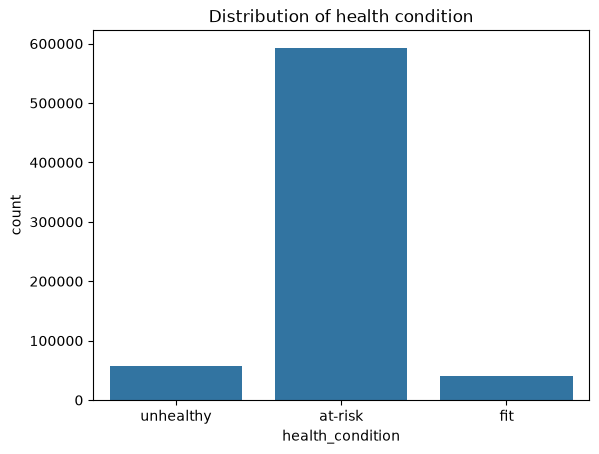

In [11]:
# Target Feature Analysis:-
print(f'Distribution of Target Feature :-\n\n{train_df['health_condition'].value_counts(normalize=True)*100}\n')

# Plot:-
plt.Figure(figsize=(6,4))
sns.countplot(data=train_df, x = 'health_condition')
plt.title('Distribution of health condition')
plt.show()

# Highly Imbalance Dataset with around 86% Students health At risk.

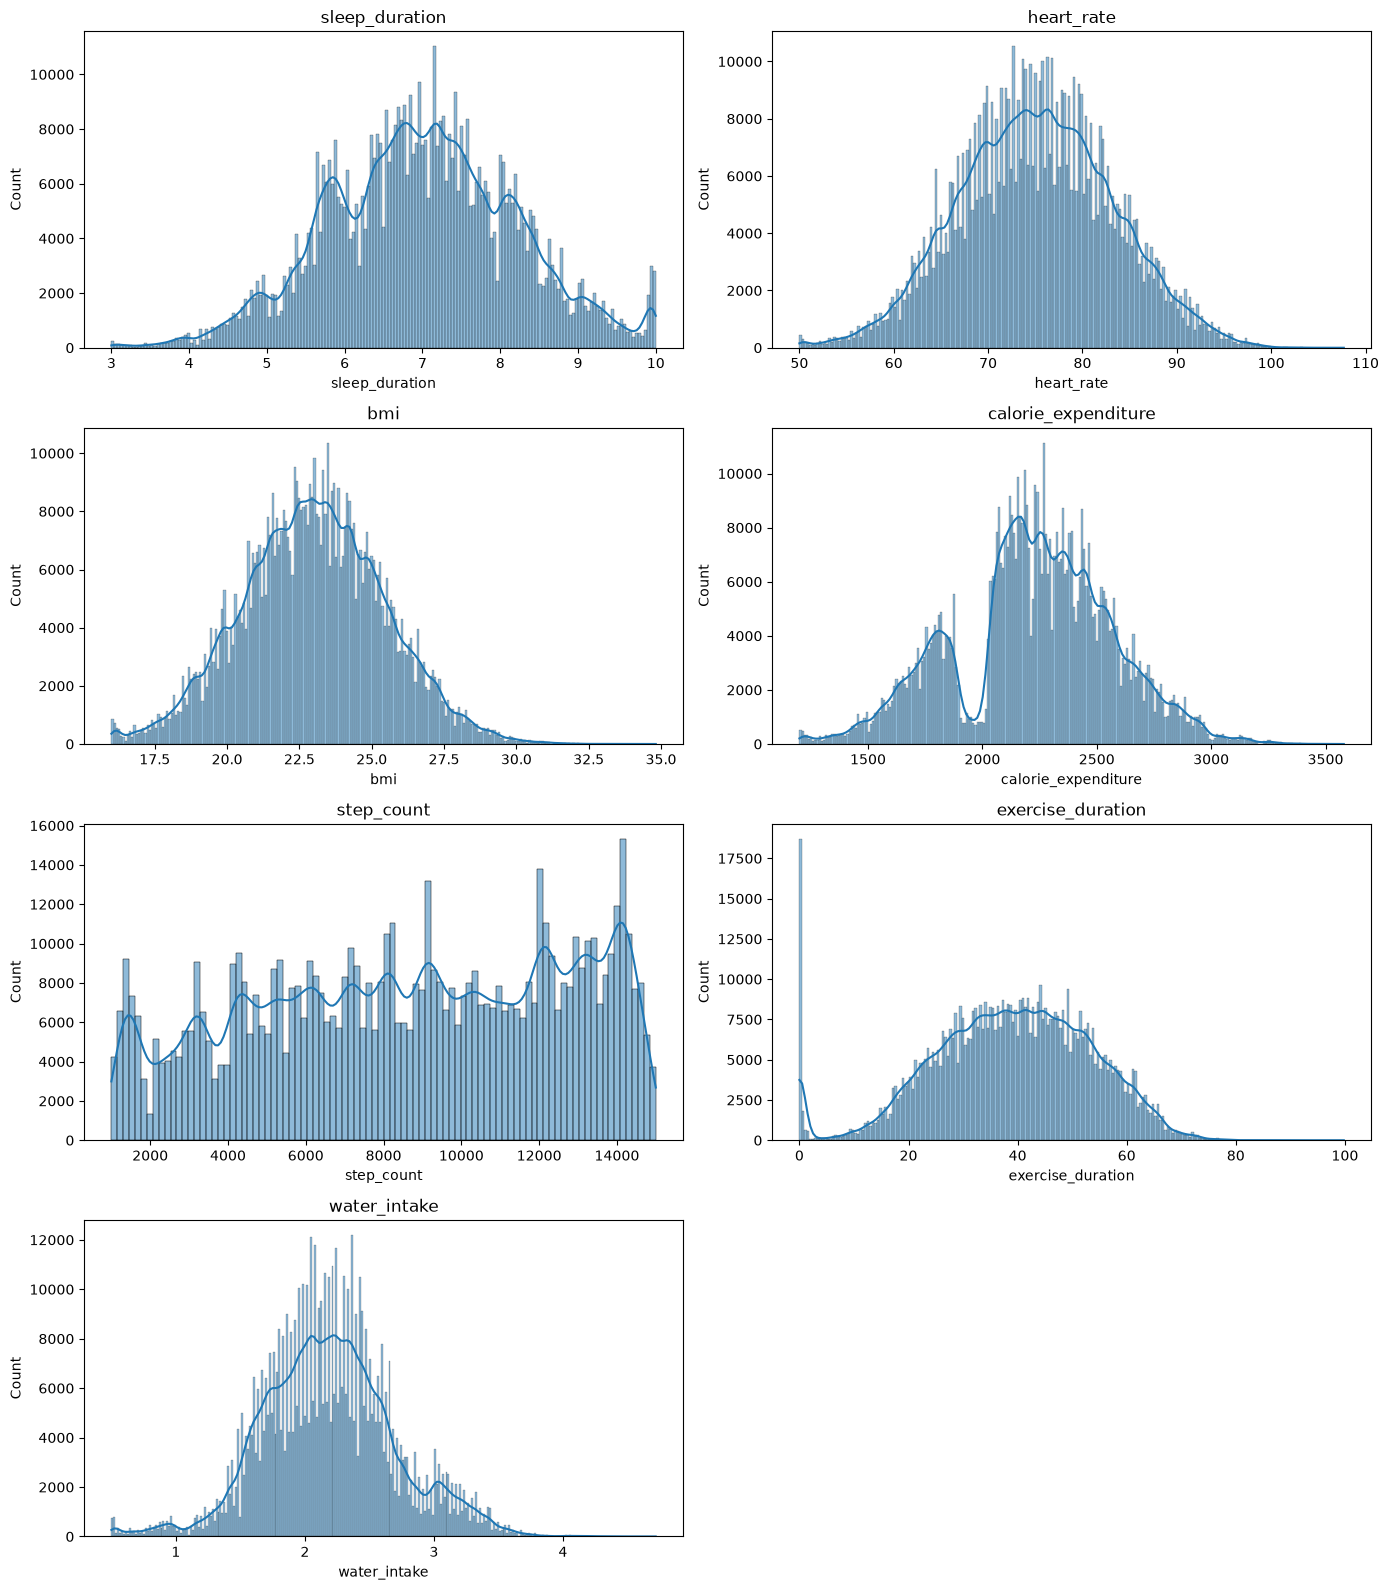

In [12]:

# numerical Features Analysis:-
num_cols = train_df.select_dtypes(include=['int','float']).columns.drop('id')

# Distribution Of numerical Features:-
cols = 2 
rows = math.ceil(len(num_cols)/cols)

fig,axes = plt.subplots(rows, cols, figsize = (14,4*rows))

axes = axes.flatten() 

for i,col in enumerate(num_cols) :

    sns.histplot(train_df[col], kde=True, ax = axes[i])
    axes[i].set_title(col)
# remove unsed subplot:
for j in range(i+1,len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Most numerical variables approximately follow a normal distribution.

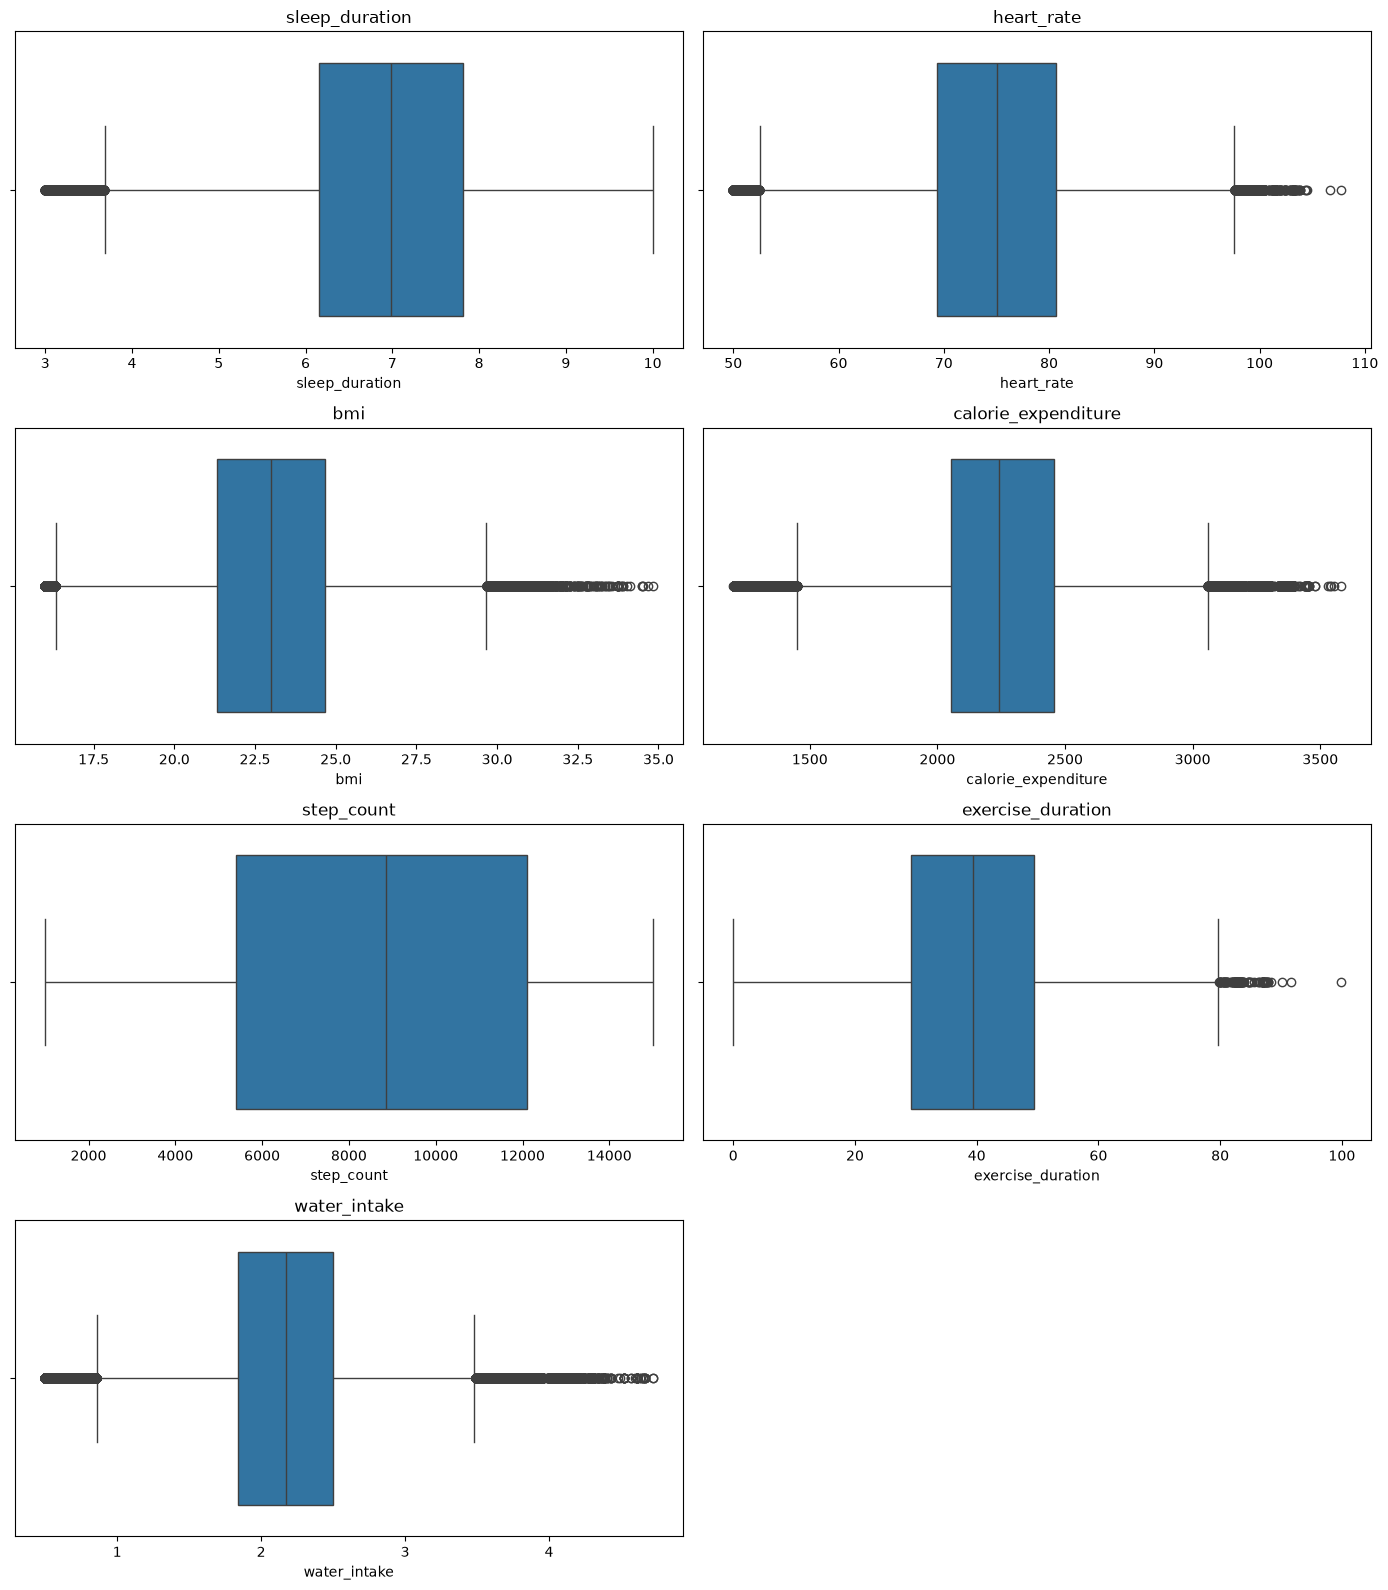

In [13]:
cols = 2
rows = math.ceil(len(num_cols) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=train_df[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# There are outliers ion almost every numeric feature but these values are not extreme these are medically possible values.
# so i am not going to treat outliers.
# No need

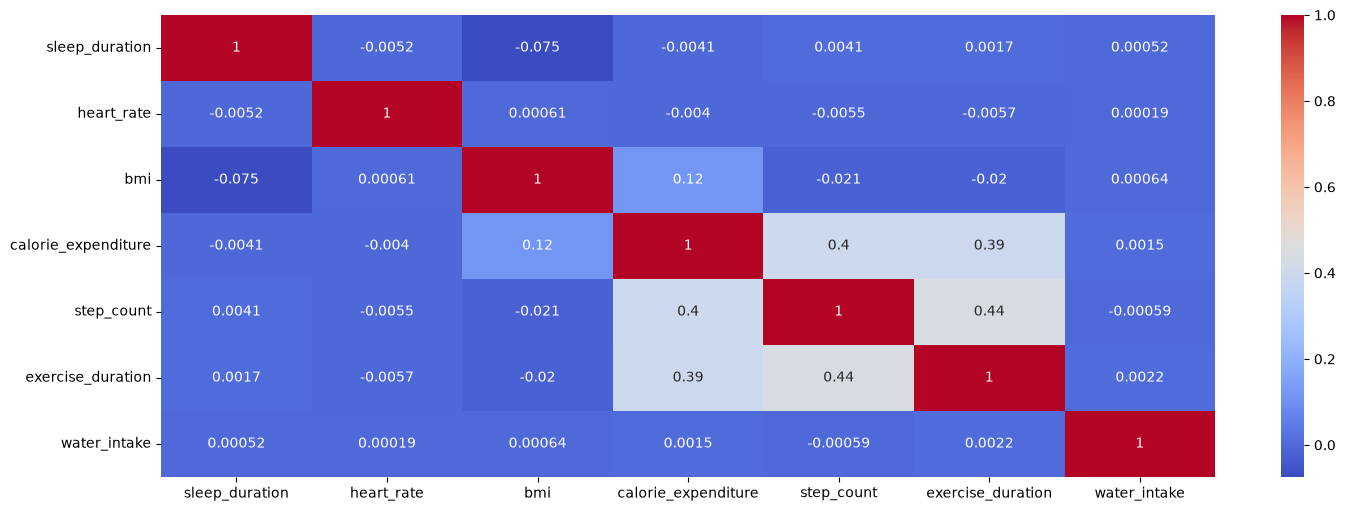

In [14]:



# Correlation Heatmap:-
plt.figure(figsize=(17,6))

sns.heatmap(train_df[num_cols].corr(),
            annot=True,
            cmap='coolwarm')

plt.show()

# Correlation Pairs:-

# Step Count <-> Exercise Duration	0.44
# Step Count <-> Calorie Expenditure	0.40
# Exercise Duration <-> Calorie Expenditure 0.39

# Others has weak correlations.

/var/folders/_c/tvlx9s_d4095pm_6bkzpnt6m0000gn/T/ipykernel_24194/316279718.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train_df.select_dtypes(include='object').columns.drop('health_condition')


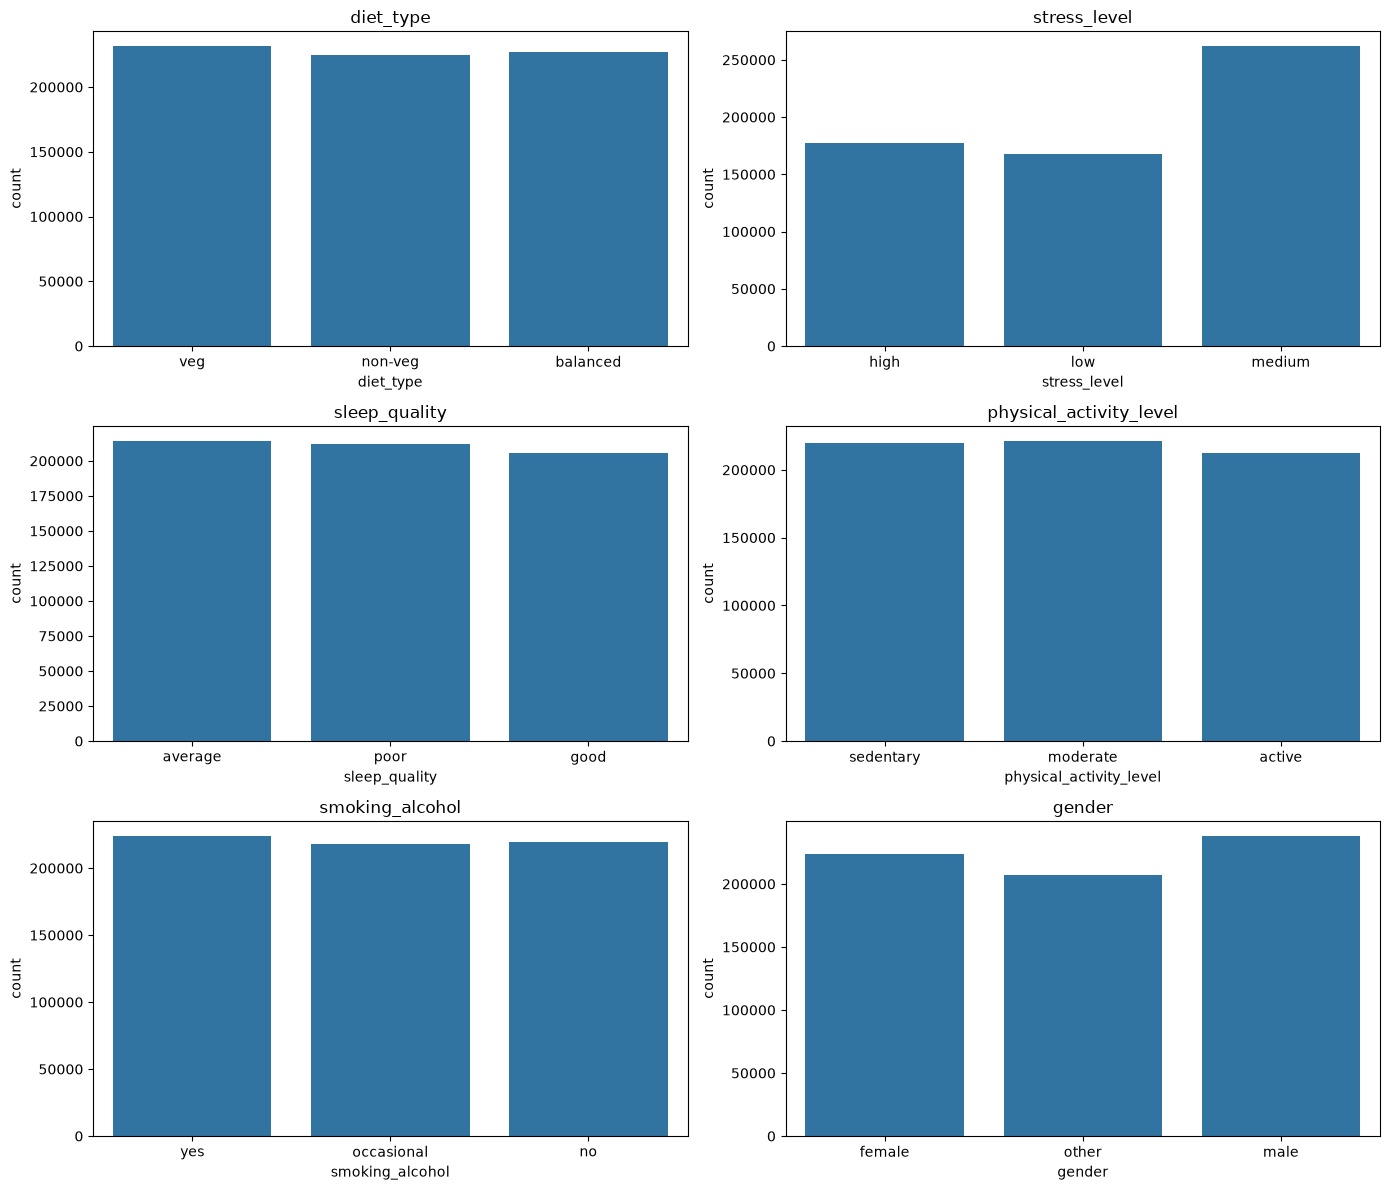

In [15]:
# Categorical Features:
cat_cols = train_df.select_dtypes(include='object').columns.drop('health_condition')

cols = 2 
rows = math.ceil(len(cat_cols)/cols)

fig,axes = plt.subplots(rows, cols, figsize = (14,4*rows))

axes = axes.flatten() 

for i,col in enumerate(cat_cols) :

    sns.countplot(x = col , data = train_df , ax = axes[i])
    axes[i].set_title(col)
# remove unsed subplot:
for j in range(i+1,len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Well distributted categorical features (3 each with some missing records.)

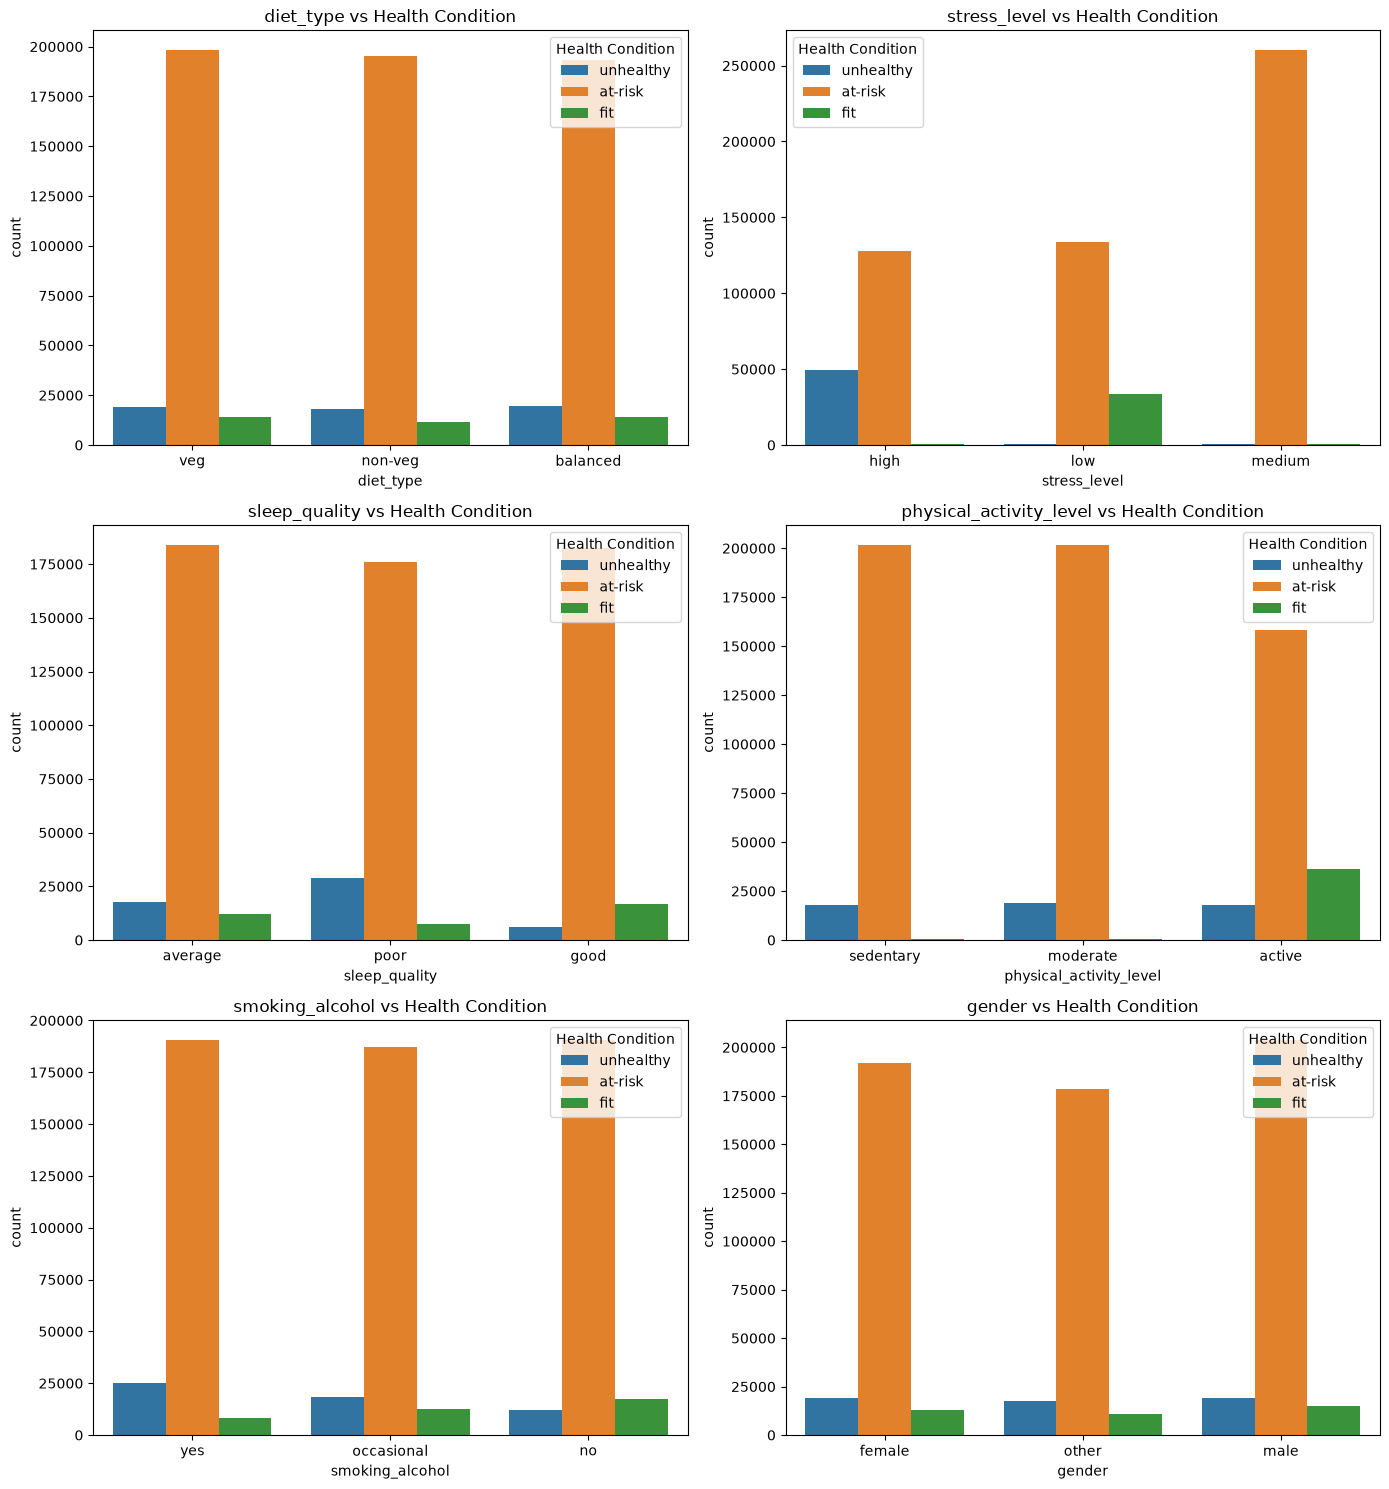

In [16]:
# Feature V/S Target:-
cols = 2
rows = math.ceil(len(cat_cols) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))

axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(
        data=train_df,
        x=col,
        hue='health_condition',
        ax=axes[i]
    )

    axes[i].set_title(f'{col} vs Health Condition')
    axes[i].tick_params(axis='x')
    axes[i].legend(title='Health Condition')

# Remove any extra subplot
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### The following features appear to have a strong relationship with the target variable:

##### Stress Level
- High stress is associated with more unhealthy students.
- Low stress has a higher proportion of fit students.
-  Physical Activity Level
- Active students are more likely to be classified as fit.
##### Sleep Quality
- Poor sleep quality is associated with unhealthy students.
- Good sleep quality is associated with fit students.
##### Smoking & Alcohol
- Shows noticeable variation across health conditions and may be an important predictor.

##### Features with relatively weaker influence:

**Diet Type**
**Gender**

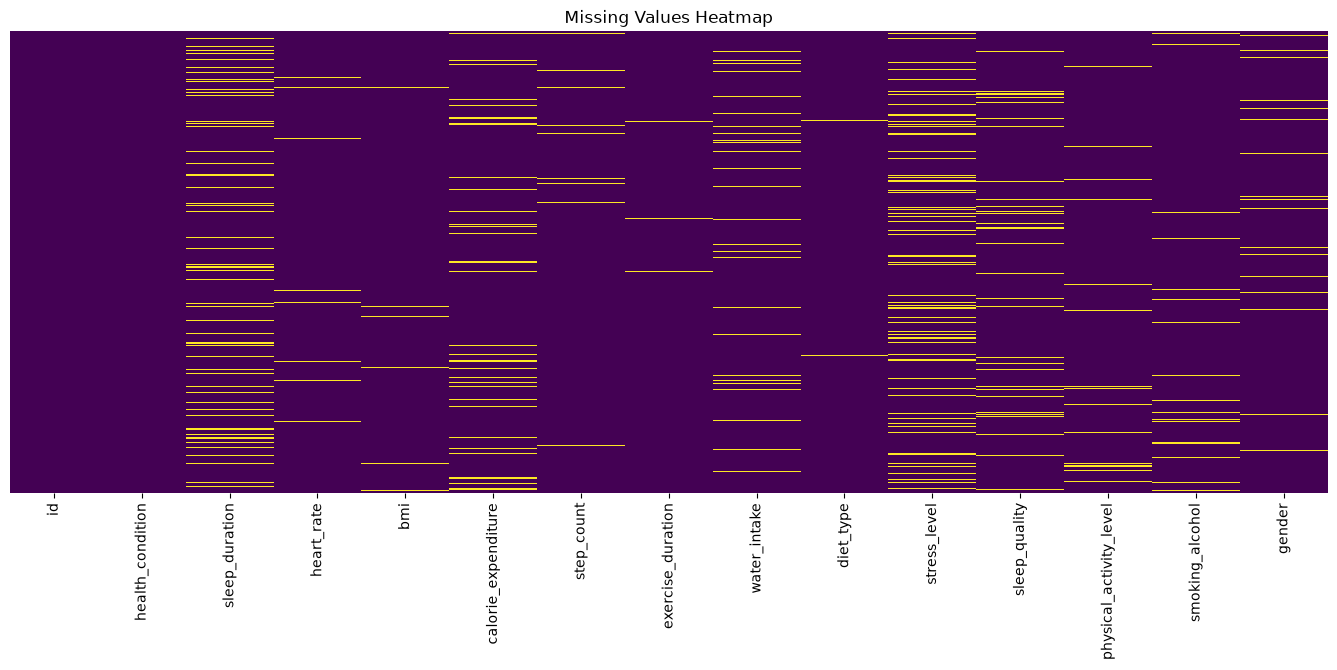

In [17]:
# Missing values Visualization:-
plt.figure(figsize=(17, 6))
sns.heatmap(train_df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

### Key EDA Findings:-
- Dataset contains moderate missing values but no duplicates.
-Numerical features have realistic distributions.
- Outliers appear to be valid observations.
- No severe multicollinearity exists.
- Several categorical features show meaningful relationships with the target.
- The target variable is highly imbalanced.


### Data Cleaning:-

In [18]:
# Remove Id Column:-
train_df.drop(columns='id', inplace= True)
test_df.drop(columns='id', inplace= True)

In [19]:
# Train - validation Split:-

X = train_df.drop('health_condition', axis = 1)
y = train_df['health_condition']

X_train,X_valid,y_train,y_valid = train_test_split(X,
                                                   y,
                                                   test_size=0.2,
                                                   random_state=42,
                                                   stratify=y)

In [20]:
#  feature type :-
num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns

cat_cols = X_train.select_dtypes(include=['object', 'string']).columns

print("Numerical Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)

Numerical Columns:
Index(['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure',
       'step_count', 'exercise_duration', 'water_intake'],
      dtype='str')

Categorical Columns:
Index(['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level',
       'smoking_alcohol', 'gender'],
      dtype='str')


In [21]:
# Pipeline for Missing imputation and Encoding :-
# numeric Pipeline :

numeric_pipeline = Pipeline(
    steps = [("imputer", SimpleImputer(strategy="median")),
             ("scaler", StandardScaler())]
    )

In [22]:
# Categorical Pipeline
categorical_pipeline = Pipeline(
    steps = [("imputer", SimpleImputer(strategy="constant",fill_value="Unknown")),
             ("encoder", OneHotEncoder(handle_unknown="ignore"))]
)

In [23]:
# Combine:-
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, num_cols),
        ('cat', categorical_pipeline, cat_cols)
    ]
)


In [24]:
X_train_processed = preprocessor.fit_transform(X_train)

X_valid_processed = preprocessor.transform(X_valid)

print(X_train_processed.shape)
print(X_valid_processed.shape)

(552070, 31)
(138018, 31)


In [25]:
rf_pipeline = Pipeline(
    steps=[('preprocessor', preprocessor),
           ('classifier',RandomForestClassifier(
                                    n_estimators=200,
                                    max_depth=30,
                                    min_samples_split=2,
                                    min_samples_leaf=2,
                                    max_features="sqrt",
                                    bootstrap=False,
                                    random_state=42,
                                    n_jobs=-1))])

rf_pipeline.fit(X_train,y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['at-risk','fit','unhealthy']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['sleep_duration','heart_rate','bmi',...,'physical_activity_level', 'smoking_alcohol','gender']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'dr

In [26]:
y_pred = rf_pipeline.predict(X_valid)
print("Accuracy :", accuracy_score(y_valid, y_pred))
print(classification_report(y_valid, y_pred))

Accuracy : 0.9661565882710951
              precision    recall  f1-score   support

     at-risk       0.97      0.99      0.98    118512
         fit       0.93      0.82      0.88      7961
   unhealthy       0.96      0.78      0.86     11545

    accuracy                           0.97    138018
   macro avg       0.95      0.87      0.91    138018
weighted avg       0.97      0.97      0.96    138018



In [37]:
# Best Features:- 
rf_model = rf_pipeline.named_steps["classifier"]

feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(by="Importance",ascending=False)

print(importance)

                                   Feature  Importance
0                      num__sleep_duration    0.366385
12                  cat__stress_level_high    0.132917
13                   cat__stress_level_low    0.100087
14                cat__stress_level_medium    0.080929
20     cat__physical_activity_level_active    0.061666
2                                 num__bmi    0.043719
5                   num__exercise_duration    0.029969
4                          num__step_count    0.029504
21   cat__physical_activity_level_moderate    0.024198
3                 num__calorie_expenditure    0.019703
11               cat__stress_level_Unknown    0.019018
1                          num__heart_rate    0.018566
6                        num__water_intake    0.017842
22  cat__physical_activity_level_sedentary    0.013252
18                 cat__sleep_quality_poor    0.008476
17                 cat__sleep_quality_good    0.007877
24                 cat__smoking_alcohol_no    0.003531
26        

In [27]:
cat_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        ("classifier",
         CatBoostClassifier(
             iterations=500,
             learning_rate=0.1,
             depth=6,

             loss_function="MultiClass",
             eval_metric="Accuracy",

             random_seed=42,
             verbose=0
         ))
    ]
)

In [28]:
cat_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['at-risk','fit','unhealthy']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['sleep_duration','heart_rate','bmi',...,'physical_activity_level', 'smoking_alcohol','gender']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'dr

In [29]:
y_pred = cat_pipeline.predict(X_valid)
y_pred = y_pred.ravel()

In [30]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_valid, y_pred))
print(classification_report(y_valid, y_pred))

Accuracy: 0.9673665753742265
              precision    recall  f1-score   support

     at-risk       0.97      0.99      0.98    118512
         fit       0.94      0.83      0.88      7961
   unhealthy       0.96      0.80      0.87     11545

    accuracy                           0.97    138018
   macro avg       0.95      0.87      0.91    138018
weighted avg       0.97      0.97      0.97    138018



In [31]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "classifier__iterations": [300, 500, 700, 1000],

    "classifier__depth": [4, 6, 8, 10],

    "classifier__learning_rate": [0.01, 0.03, 0.05, 0.1],

    "classifier__l2_leaf_reg": [1, 3, 5, 7, 9],

    "classifier__bagging_temperature": [0, 1, 3, 5],

    "classifier__random_strength": [1, 2, 5]
}

cat_random = RandomizedSearchCV(
    estimator=cat_pipeline,
    param_distributions=param_grid,

    n_iter=20,
    cv=3,

    scoring="f1_macro",

    random_state=42,
    n_jobs=-1,
    verbose=2
)
cat_random.fit(X_train, y_train)
best_cat = cat_random.best_estimator_
y_pred = best_cat.predict(X_valid)

print(classification_report(y_valid, y_pred))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END classifier__bagging_temperature=5, classifier__depth=6, classifier__iterations=300, classifier__l2_leaf_reg=9, classifier__learning_rate=0.05, classifier__random_strength=1; total time=17.2min
[CV] END classifier__bagging_temperature=5, classifier__depth=6, classifier__iterations=300, classifier__l2_leaf_reg=9, classifier__learning_rate=0.05, classifier__random_strength=1; total time=17.2min
[CV] END classifier__bagging_temperature=5, classifier__depth=6, classifier__iterations=300, classifier__l2_leaf_reg=9, classifier__learning_rate=0.05, classifier__random_strength=1; total time=17.2min
[CV] END classifier__bagging_temperature=1, classifier__depth=6, classifier__iterations=500, classifier__l2_leaf_reg=5, classifier__learning_rate=0.1, classifier__random_strength=2; total time=18.7min
[CV] END classifier__bagging_temperature=1, classifier__depth=6, classifier__iterations=500, classifier__l2_leaf_reg=5, classifier__

In [38]:
# Best Catboost Features:-
cat_model = cat_pipeline.named_steps["classifier"]

feature_names = cat_pipeline.named_steps["preprocessor"].get_feature_names_out()

# Get feature importance
importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": cat_model.get_feature_importance()
})

importance = importance.sort_values(by="Importance",ascending=False)

print(importance)

                                   Feature  Importance
0                      num__sleep_duration   30.620670
12                  cat__stress_level_high   14.596034
20     cat__physical_activity_level_active   10.871226
2                                 num__bmi   10.743861
13                   cat__stress_level_low   10.048224
14                cat__stress_level_medium    5.840925
11               cat__stress_level_Unknown    3.355206
4                          num__step_count    2.013603
5                   num__exercise_duration    1.927839
6                        num__water_intake    1.676780
19    cat__physical_activity_level_Unknown    1.584388
26                cat__smoking_alcohol_yes    1.493473
1                          num__heart_rate    1.230855
24                 cat__smoking_alcohol_no    0.873276
3                 num__calorie_expenditure    0.825436
17                 cat__sleep_quality_good    0.561733
18                 cat__sleep_quality_poor    0.476344
21   cat__

In [32]:
# Save Model
joblib.dump(best_cat, "catboost_pipeline.pkl")

['catboost_pipeline.pkl']

In [33]:
# Testing saved Model:-

loaded_model = joblib.load("catboost_pipeline.pkl")

prediction = loaded_model.predict(X_valid.iloc[:2])

print(prediction)

[['at-risk']
 ['at-risk']]


In [ ]:
# Sleep duration and stress_level are dominating features ipoertance and indeed the most important ones.